In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style for plots
sns.set_theme(style="whitegrid")

# Define paths
base_dir = Path.cwd().parent
processed_dir = base_dir / 'data' / 'processed'
visuals_dir = base_dir / 'visuals'
visuals_dir.mkdir(parents=True, exist_ok=True)

print("Loading Master Behavior (Network) Dataset...")
df = pd.read_csv(processed_dir / 'master_behavior_data.csv')

# --- DATA QUALITY REPORT ---
print("\n--- Data Quality Report ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\nMissing Values:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicate_count}")

print("\nData Overview (Info):")
df.info()

Loading Master Behavior (Network) Dataset...

--- Data Quality Report ---
Total Rows: 100000
Total Columns: 11

Missing Values:
Max Packet Length              0
Packet Length Variance         0
Avg Bwd Segment Size           0
Average Packet Size            0
Bwd Packet Length Max          0
Destination Port               0
Packet Length Std              0
Total Length of Bwd Packets    0
Subflow Fwd Bytes              0
Bwd Header Length              0
label                          0
dtype: int64

Duplicate Rows: 54269

Data Overview (Info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Max Packet Length            100000 non-null  float64
 1   Packet Length Variance       100000 non-null  float64
 2   Avg Bwd Segment Size         100000 non-null  float64
 3   Average Packet Size          100000 non-

Analyzing Target Variable (Class Distribution)...


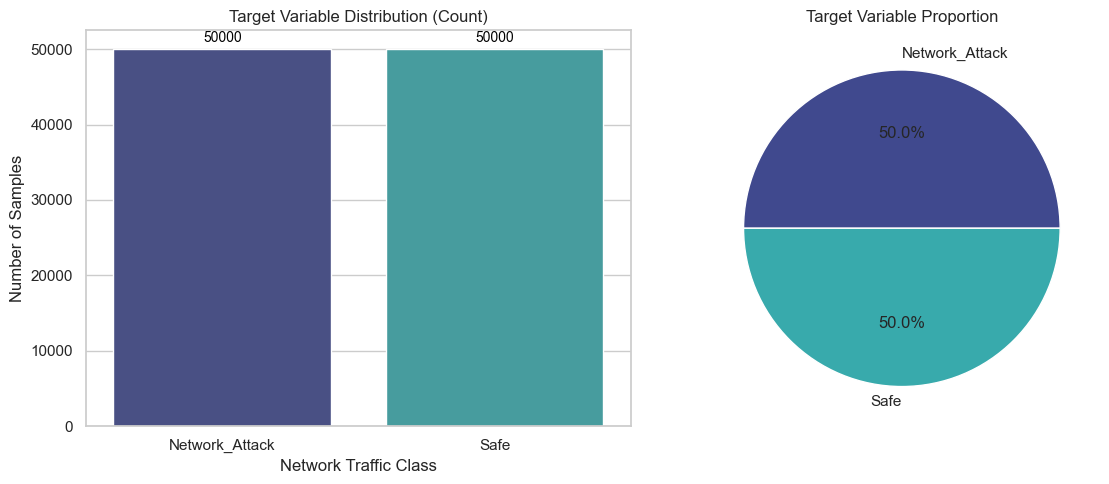

In [2]:
print("Analyzing Target Variable (Class Distribution)...")

plt.figure(figsize=(12, 5))

# Plot 1: Count Plot
plt.subplot(1, 2, 1)
ax = sns.countplot(data=df, x='label', palette='mako')
plt.title('Target Variable Distribution (Count)')
plt.xlabel('Network Traffic Class')
plt.ylabel('Number of Samples')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

# Plot 2: Pie Chart
plt.subplot(1, 2, 2)
class_counts = df['label'].value_counts()
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=sns.color_palette('mako', len(class_counts)))
plt.title('Target Variable Proportion')

plt.tight_layout()
plt.savefig(visuals_dir / 'behavior_01_target_distribution.png', dpi=300)
plt.show()

Visualizing Feature Distributions...


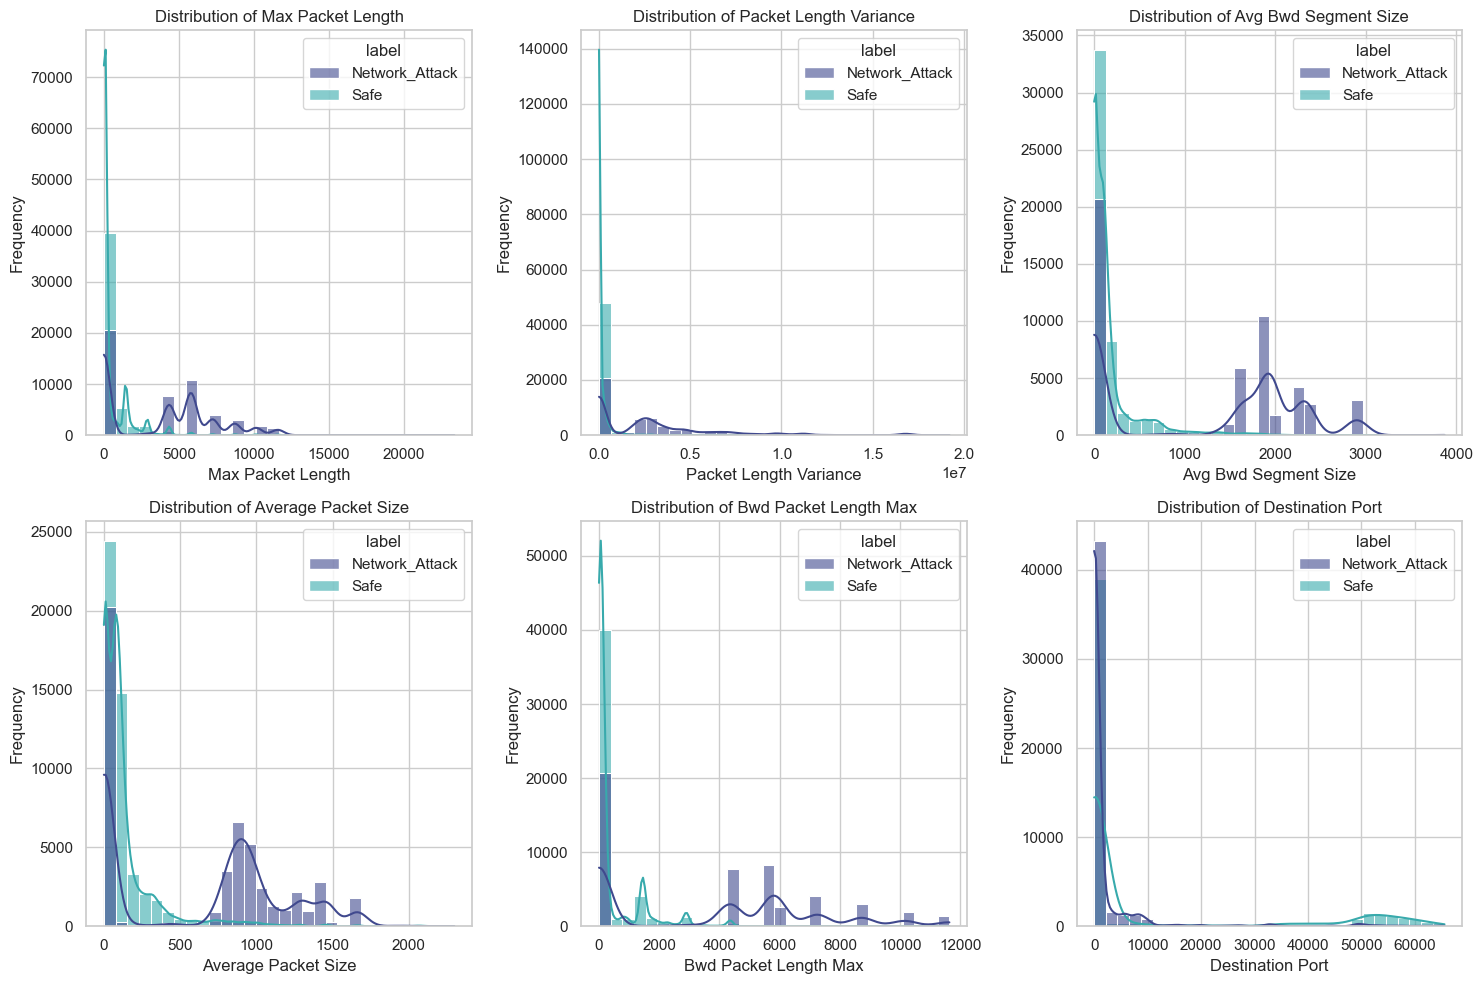

In [3]:
print("Visualizing Feature Distributions...")

# Get numeric columns only (excluding the label)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Plot histograms for top features to see data overlap
top_features_to_plot = numeric_cols[:6] # Select first 6 features for clear visualization

plt.figure(figsize=(15, 10))
for i, col in enumerate(top_features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, hue='label', bins=30, kde=True, palette='mako', alpha=0.6)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig(visuals_dir / 'behavior_02_feature_distributions.png', dpi=300)
plt.show()

Detecting Outliers using Log-Scaled Boxplots...


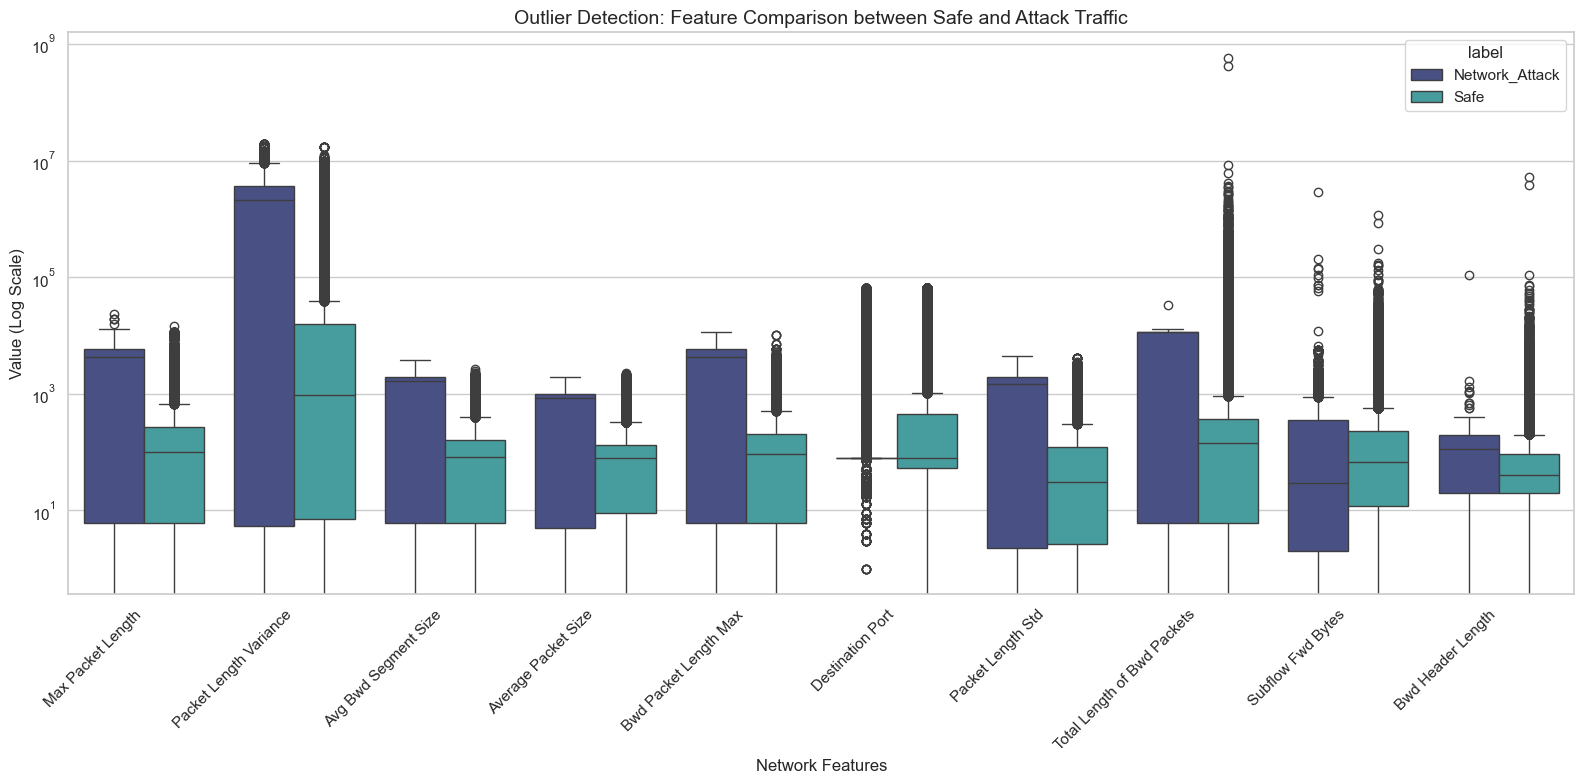

In [4]:
print("Detecting Outliers using Log-Scaled Boxplots...")

plt.figure(figsize=(16, 8))

# Create a boxplot for all numeric features, separated by class
# We use a log scale because network traffic data (like bytes) can have massive extreme values
melted_df = pd.melt(df, id_vars=['label'], value_vars=numeric_cols)

sns.boxplot(data=melted_df, x='variable', y='value', hue='label', palette='mako')
plt.title('Outlier Detection: Feature Comparison between Safe and Attack Traffic', fontsize=14)
plt.xlabel('Network Features', fontsize=12)
plt.ylabel('Value (Log Scale)', fontsize=12)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(visuals_dir / 'behavior_03_outlier_boxplots.png', dpi=300)
plt.show()

Performing Correlation Analysis...


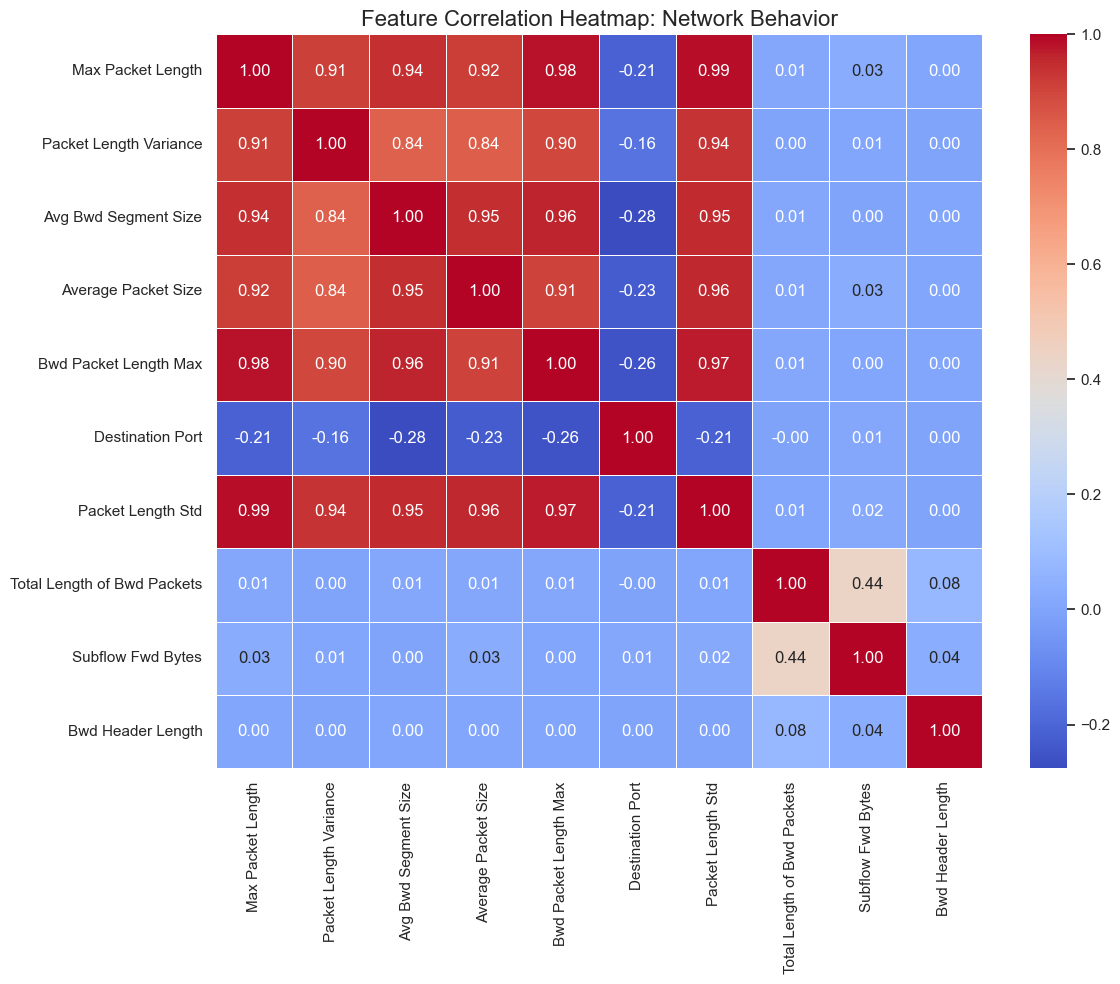


Top Absolute Correlations between features:
Packet Length Std       Max Packet Length        0.985806
Max Packet Length       Bwd Packet Length Max    0.981160
Bwd Packet Length Max   Packet Length Std        0.970216
Avg Bwd Segment Size    Bwd Packet Length Max    0.961655
Packet Length Std       Average Packet Size      0.955849
                        Avg Bwd Segment Size     0.954292
Avg Bwd Segment Size    Average Packet Size      0.946451
Max Packet Length       Avg Bwd Segment Size     0.941555
Packet Length Variance  Packet Length Std        0.936763
Average Packet Size     Max Packet Length        0.919684
dtype: float64


In [5]:
print("Performing Correlation Analysis...")

# Calculate correlation matrix for numeric features
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap: Network Behavior', fontsize=16)

plt.tight_layout()
plt.savefig(visuals_dir / 'behavior_04_correlation_heatmap.png', dpi=300)
plt.show()

# Print Top Correlations (to identify multicollinearity)
print("\nTop Absolute Correlations between features:")
# Unstack and sort the correlation matrix
c = corr_matrix.abs().unstack()
# Remove self-correlations (where correlation is exactly 1.0)
c = c[c < 1.0].sort_values(ascending=False)
# Drop duplicate pairs
c = c.drop_duplicates()
print(c.head(10))

Running Principal Component Analysis (PCA)...


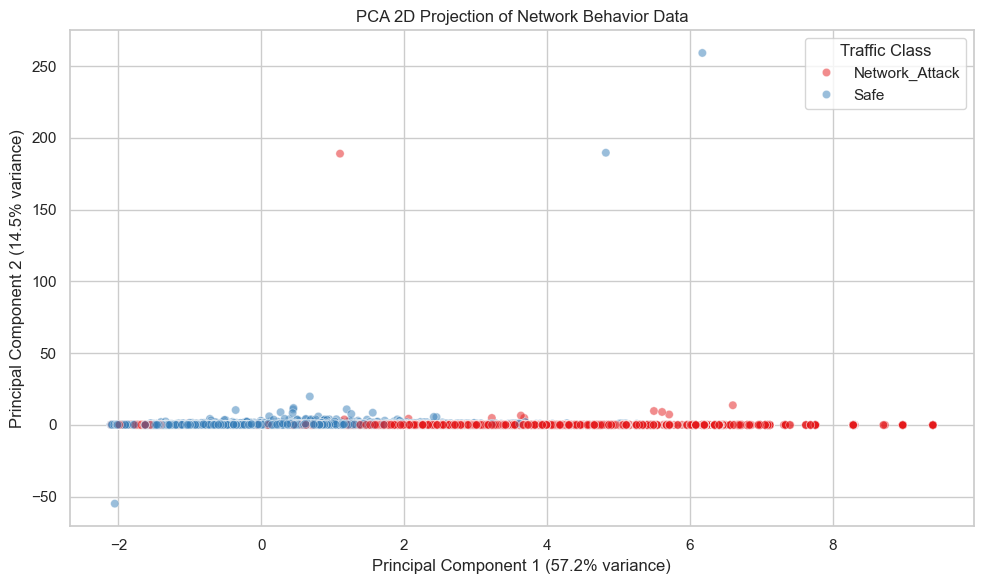

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Running Principal Component Analysis (PCA)...")

# 1. Standardize the data first (Crucial for PCA as network features have different scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

# 2. Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df['label'], palette='Set1', alpha=0.5)
plt.title('PCA 2D Projection of Network Behavior Data')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Traffic Class')

plt.tight_layout()
plt.savefig(visuals_dir / 'behavior_05_pca_projection.png', dpi=300)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

print("Preparing Data for Model Training (Train/Test Split)...")

# Separate features (X) and target (y)
X = df.drop(columns=['label'])
y = df['label']

# Split the dataset: 80% for training, 20% for testing
# stratify=y ensures the 50/50 balance is maintained in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- Data Split Report ---")
print(f"Total Dataset Size: {len(X)} rows")
print(f"Training Set Size: {len(X_train)} rows (80%)")
print(f"Testing Set Size: {len(X_test)} rows (20%)")

print("\nTraining Set Class Distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Set Class Distribution:")
print(y_test.value_counts(normalize=True) * 100)

print("\nEDA and Data Split Complete. Ready for Model Training!")

Preparing Data for Model Training (Train/Test Split)...

--- Data Split Report ---
Total Dataset Size: 100000 rows
Training Set Size: 80000 rows (80%)
Testing Set Size: 20000 rows (20%)

Training Set Class Distribution:
label
Network_Attack    50.0
Safe              50.0
Name: proportion, dtype: float64

Testing Set Class Distribution:
label
Safe              50.0
Network_Attack    50.0
Name: proportion, dtype: float64

EDA and Data Split Complete. Ready for Model Training!
